# Task A. Affine Cipher (10 marks)

In this task, we aim to solidify students’ understanding of historical ciphers, more specifically the Affine cipher. In the following source code, we have implemented an extended version of the Affine cipher where the extended alphabet contains much more printable characters than the 26 letters. 
* The encryption and decryption functions have been implemented and are ready for use.
* Throughout Task A, we set the alphabet with the printable characters in the range from ‘ ’ to ‘\~’ (inclusive). Please refer to https://www.ascii-code.com the more details about ASCII code table. Each character/symbol corresponds to a numer between $0$ (inclusive) and the size of the alphabet (exclusive), i.e., ' ' corresponds to $0$, and '\~' corresonds to $94$.
* In the example, we have demonstrated how to encrypt plaintext and decrypt ciphertext with a pair of keys. 

### Install EGCD package

In order to run the following programs, you need to install a Python package called *egcd* which is a basic, efficient, and pure-Python implementation of the extended Euclidean algorithm. Information can be found here: https://egcd.readthedocs.io/en/0.6.0/

The command to install this package: *pip install egcd*

In [1]:
pip install egcd

Note: you may need to restart the kernel to use updated packages.


In [3]:
#=====================================================
# Please do NOT modify the following code, but you are more than welcome to understand the code in detail

import sys
import math
from egcd import egcd
    
class ExtendedAffineCipher:
    
    def __init__(self, alphabet_start, alphabet_end):
        self.alphabet_start = alphabet_start
        self.ord_start = ord(self.alphabet_start[0])
        self.alphabet_end = alphabet_end
        self.alphabet_size = ord(alphabet_end[0])-ord(alphabet_start[0])+1
    
    
    def get_alphabet_size(self):
        return self.alphabet_size
         
    
    def encrypt(self, plain_text, key_a, key_b):
        
        if None == plain_text:
            sys.exit('No plain text to encrypt!')
        
        # Check if the input is legitimate
        for i in plain_text:
            if self.alphabet_start > i and self.alphabet_end < i:
                sys.exit('Illegimate char in the plain text, check against the alphabet set!')
                
        # Check if key_a is a legitimate key
        if not self.is_coprime(key_a, self.alphabet_size):
            sys.exit('The parameter key_a is not set appropriately. Please select a value co-prime with the alphabet size!')
        else:
            key_a = key_a%self.alphabet_size
            key_b = key_b%self.alphabet_size
        
        cipher_text = ""
        for i in plain_text:
            cipher_text += chr((key_a*(ord(i)-self.ord_start)+key_b)%self.alphabet_size + self.ord_start)
        return cipher_text
    
    
    # We use the analytical way with the extended Euclidean Algorithm (note, an exhaustive way might be also possible)
    def decrypt(self, cipher_text, key_a, key_b):
        
        if None == cipher_text:
            sys.exit('No plain text to encrypt!')
        
        # Check if the input is legitimate
        for i in cipher_text:
            if self.alphabet_start > i and self.alphabet_end < i:
                sys.exit('Illegimate char in the plain text, check against the alphabet set!')
                        
        # Check if key_a is a legitimate key
        if not self.is_coprime(key_a, self.alphabet_size):
            sys.exit('The parameter key_a is not set appropriately. Please select a value co-prime with the alphabet size!')
        else:
            key_a = key_a%self.alphabet_size
            key_b = key_b%self.alphabet_size
        
        plain_text=""
        for i in cipher_text:
            plain_text += chr(self.multiplicative_inverse_with_egcd(key_a, key_b, (ord(i)-self.ord_start), self.alphabet_size) + self.ord_start)
        
        return plain_text

        
    # A function determines if two values are coprime
    def is_coprime(self, a, b):
        
        # Use the greatest common divisor (GCD) for the decision
        return 1 == math.gcd(a, b)
    
    
    # Solve equation: a * x + b = c (mod n)
    def multiplicative_inverse_with_egcd(self, a, b, c, n):
       
        # Solve a * y = gcd(a, n) (mod n) using EGCD
        tuple = egcd(a, n)
        y = tuple[1]
        gcd = tuple[0]
        
        # Now we have a * y * (c-b)/gcd(a, n) = (c-b) (mod n). If gcd != 1, there are multiple solutions (even less then n), we get the smallest one.
        x = (y*int(((c-b+n)%n)/gcd))%int(n/gcd)
        
        return x

#=====================================================
# Examples of using the extended affine cipher
# Please do NOT alter this part. In Task A, we will use the same alphabet as in the follow example.

# Define an extended affine cipher where the alphabet set ranges from ' ' to '~' (corresponding the printable characters).
cipher = ExtendedAffineCipher(' ', '~')
print("Alphabet size is: ", cipher.get_alphabet_size())

# Encrypt a plain text with the key pair (11, 10)
cipher_text = cipher.encrypt("Hello World, COMP2300/6300!", 11, 10)
print("The example cipher text is: ", cipher_text)

# Decrypt the cipher text generated above
plain_text = cipher.decrypt(cipher_text, 11, 10)
print("The example plain text is: ", plain_text)
print("")

Alphabet size is:  95
The example cipher text is:  f)vv8*M8Yv}O*/T>_2={{p^={{5
The example plain text is:  Hello World, COMP2300/6300!



## Task A.1 (3 marks)

Using the **same setting** as the examples (i.e., the same extended Affine cipher). Each character/symbol can be encoded as a numer between $0$ (inclusive) and the size of the alphabet (exclusive), i.e., ' ' corresponds to $0$, and '\~' corresonds to $94$. So, we can choose the values in this range for "key_a" and "key_b". Now we treat a student ID, which is a sequence of numbers, as an integer and use it to derive the value for "key_a". Specifically, we use the value $\text{<AStudentID>}~ (\text{mod}~N)$ for "key_a", where <AStudentID> is a student ID and $N$ is the size of the alphabet.

**Question A.1.1 (1.5 mark)**: For a given student ID, what is the probability of the derived value being an **appropriate** "key_a"? Please plain why with showing the necessary intermdiate steps of calculating the probability.

**Answer**:

**Question A.1.2 (0.5 mark)**: What is the probability of the derived value from your own student ID being an **appropriate** "key_a"?

**Answer**:

**Task A.1 Source Code (1 mark)**

In [5]:
# TODO: Your code





## Task A.2 (2 marks)

Choose an appropriate key pair to encrypt the plaintext "Hello everyone, welcome to Applied Cryptography!". You **MUST** use "key_a" derived from your student ID (i.e., $\text{<YourStudentID>}~ (\text{mod}~N)$) if it is appropriate. Otherwise, you can randomly choose an appropriate value for "key_a". As to "key_b", you can randomly choose an appropriate value.

**Question A.2.1 (0.5 mark)**: What is your chosen key pair?

**Answer**:

**Question A.2.2 (0.5 mark)**: What is the corresponding ciphertext?

**Answer**:

**Task A.2 Source Code (1 mark)**

In [7]:
# Task A.2 source code
plain_text_A_2 = "Hello everyone, welcome to Applied Cryptography!"

# TODO: Your code
# Obtain "key_a" and "key_b" to encrypt the message
# key_a_A_2 = ?
# key_b_A_2 = ?



## Task A.3 (5 marks)

In this task, you are required to decrypt a given piece of cipher text without knowing the key pair, i.e., both “key_a” and “key_b” are unknown. Now, you are given a piece of cipher text **1YS(\_S{o(soSQ([e(/sMqKo\_(lDN(KmS\\(qYS(oqsQSeq(zp(PHHHHHHH(Ugm(+sSoq[ge(lDNDJ@(KeQ({gsm(gwe(oqsQSeq(zp(Ugm(+sSoq[ge(lDNDLD**, but the key pair is missing. 
* Your task is to figure out the key pair and decrypt the cipher text. The corresponding plain text is a meaningful piece of text which offers important information the Task B and Task C.
* In a trial, a hacker has performed some frequency analysis and figured out that (1) the most frequent characters in the plain text are the Space and the letter 'e', and (2) the plain text contains the string "Subtask B.3". This information might be helpful for your cryptoanalysis. 
* There are two options to achieve this task. **You need to attempt BOTH options**.
  * Option 1 is to use the exhaustive method to try all the possible keys (simple but requires more computation). You are required to only try the appropriate keys.
  * Option 2 is to use analytical analysis with solving a system of equations, which would be more advanced and efficient. You might use our defined function *ExtendedAffineCipher.multiplicative_inverse_with_egcd()* to help you to solve the system of euations. So, please read the given source code carefully for useful information.

**Question A.3.1 (0.5 mark)**: For Option 1, what is the theoretical number of key pairs you have to try in the worst case?

**Answer**:

**Question A.3.2 (0.5 mark)**: For Option 1, what is the actual number of key pairs you have tried in your program to obtain the right key pair?

**Answer**:

**Question A.3.3 (1 mark)**: For Option 2, what is the system of equations and how did you build it?

**Answer**:

**Question A.3.4 (1 mark)**: What is the identified key pair?

**Answer**:

**Question A.3.5 (1 mark)**: What is the deciphered plaintext?

**Answer**:

**Task A.3 Source Code (1 mark)**

In [15]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

# Task A.3 source code
cipher_text_A_3 = "1YS(_S{o(soSQ([e(/sMqKo_(lDN(KmS\(qYS(oqsQSeq(zp(PHHHHHHH(Ugm(+sSoq[ge(lDNDJ@(KeQ({gsm(gwe(oqsQSeq(zp(Ugm(+sSoq[ge(lDNDLD"

# TODO: Your code to decrypt the cipher text

# You need to attempt both options

# Option 1: A loop can be used to search the key pairs in an exhaustive way.

# Option 2: Analytical inference




# Appendix A - ASCII printable characters (character code 32-127)

Codes 32-127 are common for all the different variations of the ASCII table, they are called printable characters, represent letters, digits, punctuation marks, and a few miscellaneous symbols. You will find almost every character on your keyboard. Character 127 represents the command DEL. Refer to https://www.ascii-code.com/ for more details about ASCII code.

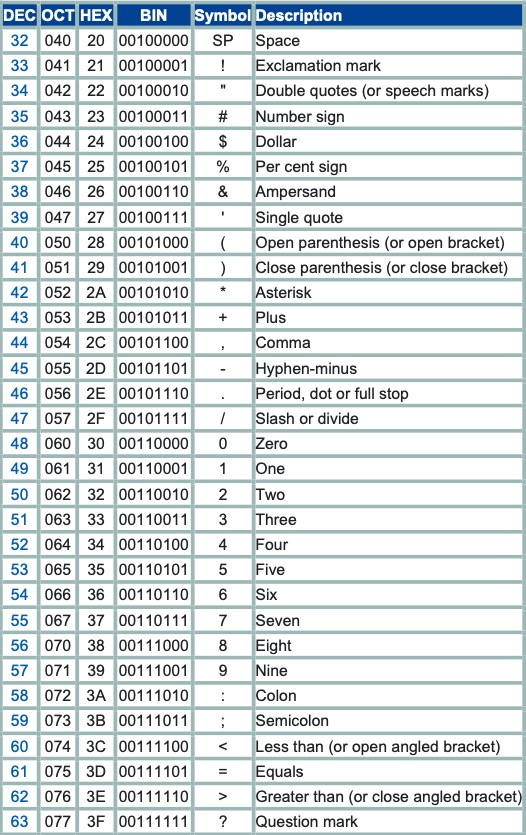

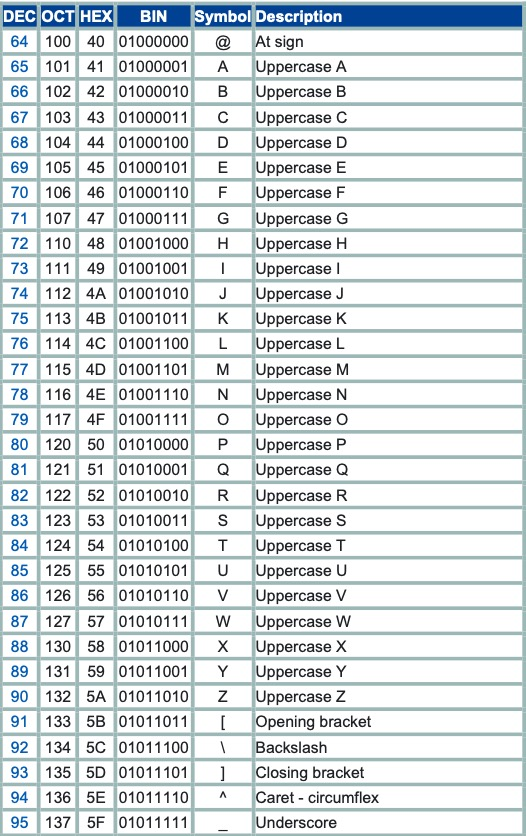

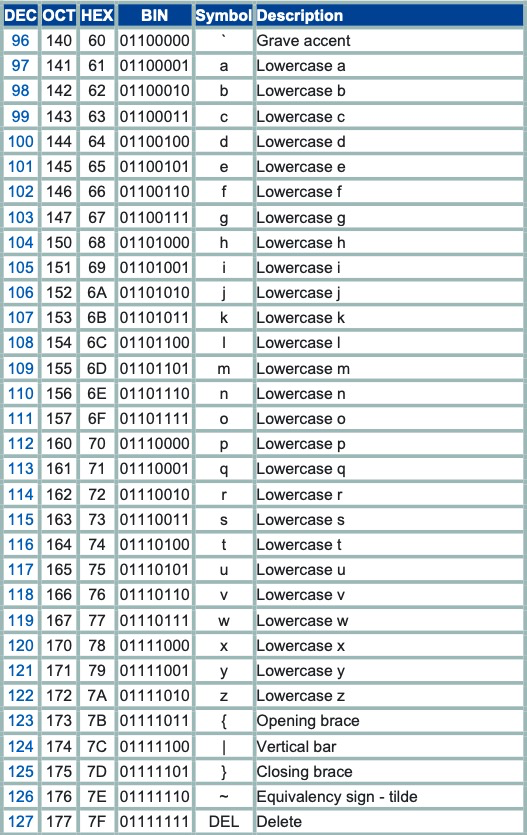